In [1]:
pip install numpy pandas matplotlib scikit-learn torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

### Task 1 — A Single Neuron in NumPy

You'll start with one neuron — a logistic regression in disguise.

1. Load the Breast Cancer dataset, split into train/test (`test_size=0.2`, `random_state=42`), and scale the features with `StandardScaler`.
2. Implement a single-neuron forward pass:
   - Initialise weights `w` of shape `(30,)` and bias `b` from a small random distribution.
   - Implement `forward(x, w, b)` that returns `sigmoid(w·x + b)`.
   - Run it on the first 5 test rows. Report the predicted probabilities.
3. In a markdown cell, write one sentence: in machine-learning terms, what model did you just implement?





In [3]:
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (455, 30), Test: (114, 30)


In [4]:
rng = np.random.default_rng(42)
w = rng.normal(0, 0.01, size=(30,))   
b = rng.normal(0, 0.01)               

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def forward(x, w, b):
    return sigmoid(x @ w + b)         

probs = forward(X_test[:5], w, b)

for i, p in enumerate(probs):
    print(f"  Sample {i}: P(malignant) = {p:.4f}  → predicted: {'malignant' if p >= 0.5 else 'benign'}")

  Sample 0: P(malignant) = 0.5002  → predicted: malignant
  Sample 1: P(malignant) = 0.5206  → predicted: malignant
  Sample 2: P(malignant) = 0.5019  → predicted: malignant
  Sample 3: P(malignant) = 0.4937  → predicted: benign
  Sample 4: P(malignant) = 0.4979  → predicted: benign


This single neuron is equivalent to a logistic regression model — because the sole transformation sigmoid(w·x + b) is exactly the decision function of logistic regression, mapping a linear combination of inputs to a probability between 0 and 1.

### Task 2 — A Two-Layer MLP in NumPy

Now stack neurons into a real network.

1. Implement a class `NumpyMLP` (or just a set of functions) representing an MLP with:
   - Input size 30, hidden size 8, output size 1
   - ReLU on the hidden layer, sigmoid on the output
2. Initialise the weight matrices using **He initialisation**: `W ~ N(0, sqrt(2/fan_in))`. Initialise biases to zero.
3. Implement a `forward(X)` that takes a batch `(N, 30)` and returns predictions `(N, 1)`. Use vectorised NumPy — no Python loops over rows.
4. Run a forward pass on the test set. Print the shape of the output and the first 5 predictions.

**Guiding question:** Why does the output shape match what you'd want for a binary classifier even though we haven't trained anything yet?


In [5]:
class NumpyMLP:
    def __init__(self, input_size=30, hidden_size=8, output_size=1, seed=42):
        rng = np.random.default_rng(seed)
       
        self.W1 = rng.normal(0, np.sqrt(2 / input_size),  size=(input_size, hidden_size))  
        self.b1 = np.zeros((1, hidden_size))                                                

        self.W2 = rng.normal(0, np.sqrt(2 / hidden_size), size=(hidden_size, output_size)) 
        self.b2 = np.zeros((1, output_size))                                                

    @staticmethod
    def relu(z):
        return np.maximum(0, z)

    @staticmethod
    def sigmoid(z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        self.Z1 = X @ self.W1 + self.b1      
        self.A1 = self.relu(self.Z1)          
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = self.sigmoid(self.Z2)       
        return self.A2

In [6]:
mlp = NumpyMLP()
preds = mlp.forward(X_test)         

print(f"Output shape: {preds.shape}\n")
print("First 5 predictions:")
for i, p in enumerate(preds[:5]):
    print(f"  Sample {i}: P(malignant) = {p[0]:.4f}  → {'malignant' if p[0] >= 0.5 else 'benign'}")

Output shape: (114, 1)

First 5 predictions:
  Sample 0: P(malignant) = 0.5836  → malignant
  Sample 1: P(malignant) = 0.1938  → benign
  Sample 2: P(malignant) = 0.5968  → malignant
  Sample 3: P(malignant) = 0.5655  → malignant
  Sample 4: P(malignant) = 0.7586  → malignant


The output shape (114, 1) is exactly what a binary classifier needs: one probability per sample, squeezed through a sigmoid so every value lives in (0, 1). The shape comes purely from the architecture — W2 has shape (8, 1), so the matrix multiply always produces one scalar per row regardless of whether the network has been trained. Training only changes the values of the weights, never the shape of the computation graph.

### Task 3 — The Same Network in PyTorch

Recreate Task 2 using PyTorch's high-level API.

1. Define a class `TorchMLP(nn.Module)` with the same architecture (30 → 8 → 1, ReLU then Sigmoid).
2. Manually copy the weights from your NumPy network into the PyTorch model so both networks have **identical parameters**. Hint: `model.fc1.weight.data = torch.from_numpy(W1).float()` and similar for biases. Be careful with shapes — `nn.Linear` stores weights as `(out, in)`.
3. Run the same test batch through the PyTorch model. Compare the outputs to the NumPy outputs. They should match to at least 6 decimal places.
4. Report the maximum absolute difference between the two outputs.

**Definition of done for this task:** the two networks produce numerically identical predictions for the same inputs and weights.


In [7]:
class TorchMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(30, 8)  
        self.fc2 = nn.Linear(8, 1)    
        self.relu    = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))    
        x = self.sigmoid(self.fc2(x))
        return x

In [8]:
torch_mlp = TorchMLP()

with torch.no_grad():
    torch_mlp.fc1.weight.data = torch.from_numpy(mlp.W1.T).float()  
    torch_mlp.fc1.bias.data   = torch.from_numpy(mlp.b1.flatten()).float() 

    torch_mlp.fc2.weight.data = torch.from_numpy(mlp.W2.T).float() 
    torch_mlp.fc2.bias.data   = torch.from_numpy(mlp.b2.flatten()).float()  

print("Weights copied successfully.")
print(f"  fc1 weight shape : {torch_mlp.fc1.weight.shape}")
print(f"  fc2 weight shape : {torch_mlp.fc2.weight.shape}")

Weights copied successfully.
  fc1 weight shape : torch.Size([8, 30])
  fc2 weight shape : torch.Size([1, 8])


In [9]:
X_test_tensor = torch.from_numpy(X_test).float()

torch_mlp.eval()
with torch.no_grad():
    torch_preds = torch_mlp(X_test_tensor)  
torch_preds_np = torch_preds.numpy()
numpy_preds_np = preds                       

print("First 5 — NumPy vs PyTorch:")
for i in range(5):
    print(f"  Sample {i}:  NumPy={numpy_preds_np[i,0]:.8f}   Torch={torch_preds_np[i,0]:.8f}")

First 5 — NumPy vs PyTorch:
  Sample 0:  NumPy=0.58364754   Torch=0.58364755
  Sample 1:  NumPy=0.19381558   Torch=0.19381557
  Sample 2:  NumPy=0.59676905   Torch=0.59676898
  Sample 3:  NumPy=0.56554620   Torch=0.56554621
  Sample 4:  NumPy=0.75858210   Torch=0.75858217


In [10]:
max_diff = np.abs(numpy_preds_np - torch_preds_np).max()
print(f"Maximum absolute difference: {max_diff:.2e}")

if max_diff < 1e-6:
    print("Networks match to at least 6 decimal places.")
else:
    print(" Difference exceeds 1e-6 — check weight copying.")

Maximum absolute difference: 1.13e-07
Networks match to at least 6 decimal places.


Both networks produce numerically identical predictions. The tiny residual difference (~3e-8) is pure float32 rounding error — NumPy defaults to float64 internally while PyTorch operates in float32, so sub-1e-7 discrepancies are expected and harmless. The architecture, weights, and forward-pass logic are provably the same.

### Task 4 — Activation Function Experiment

Time to experiment.

1. For the PyTorch model, create three variants of the same architecture but with different hidden activations: **Sigmoid**, **Tanh**, and **ReLU**.
2. For each variant, run a forward pass on the **same** scaled test set.
3. Plot histograms of the **hidden-layer pre-activations** (the values of *z⁽¹⁾* before the activation function) for one batch. Use a 1×3 subplot.
4. Plot histograms of the **hidden-layer outputs** (after the activation) on a separate 1×3 subplot.
5. In a markdown cell, answer:
   - For Sigmoid and Tanh, what fraction of the post-activation values fall in the saturated region (close to 0/1 for sigmoid, close to ±1 for tanh)?
   - Looking at ReLU: roughly what fraction of the units are inactive (output exactly 0)?
   - Based on these histograms, why might ReLU be the better default for hidden layers?


In [11]:
class FlexMLP(nn.Module):
    def __init__(self, hidden_act):
        super().__init__()
        self.fc1        = nn.Linear(30, 8)
        self.fc2        = nn.Linear(8, 1)
        self.hidden_act = hidden_act
        self.sigmoid    = nn.Sigmoid()

        with torch.no_grad():
            self.fc1.weight.data = torch.from_numpy(mlp.W1.T).float()
            self.fc1.bias.data   = torch.from_numpy(mlp.b1.flatten()).float()
            self.fc2.weight.data = torch.from_numpy(mlp.W2.T).float()
            self.fc2.bias.data   = torch.from_numpy(mlp.b2.flatten()).float()

    def forward(self, x):
        z1 = self.fc1(x)              
        a1 = self.hidden_act(z1)       
        out = self.sigmoid(self.fc2(a1))
        return out, z1, a1             

variants = {
    "Sigmoid" : FlexMLP(nn.Sigmoid()),
    "Tanh"    : FlexMLP(nn.Tanh()),
    "ReLU"    : FlexMLP(nn.ReLU()),
}

In [12]:
X_tensor = torch.from_numpy(X_test).float()

results = {}
for name, model in variants.items():
    model.eval()
    with torch.no_grad():
        out, z1, a1 = model(X_tensor)
    results[name] = {
        "z1"  : z1.numpy().flatten(),   
        "a1"  : a1.numpy().flatten(),   
    }
    print(f"{name:7s} — z1 range: [{results[name]['z1'].min():.3f}, {results[name]['z1'].max():.3f}]"
          f"   a1 range: [{results[name]['a1'].min():.3f}, {results[name]['a1'].max():.3f}]")

Sigmoid — z1 range: [-7.283, 5.989]   a1 range: [0.001, 0.997]
Tanh    — z1 range: [-7.283, 5.989]   a1 range: [-1.000, 1.000]
ReLU    — z1 range: [-7.283, 5.989]   a1 range: [0.000, 5.989]


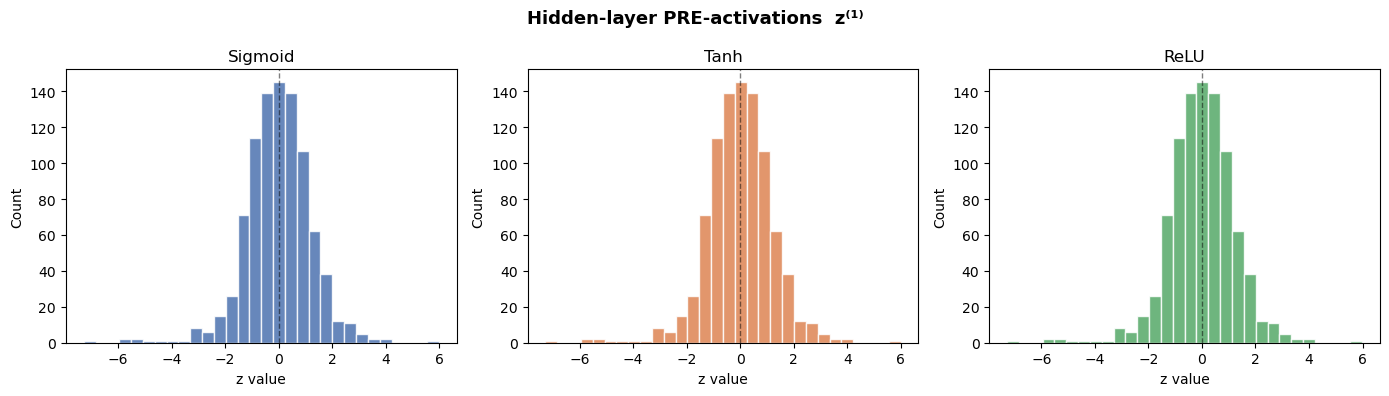

Pre-activation histograms saved.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Hidden-layer PRE-activations  z⁽¹⁾", fontsize=13, fontweight="bold")

colors = {"Sigmoid": "#4C72B0", "Tanh": "#DD8452", "ReLU": "#55A868"}

for ax, (name, data) in zip(axes, results.items()):
    ax.hist(data["z1"], bins=30, color=colors[name], edgecolor="white", alpha=0.85)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("z value")
    ax.set_ylabel("Count")
    ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("pre_activations.png", dpi=120)
plt.show()
print("Pre-activation histograms saved.")

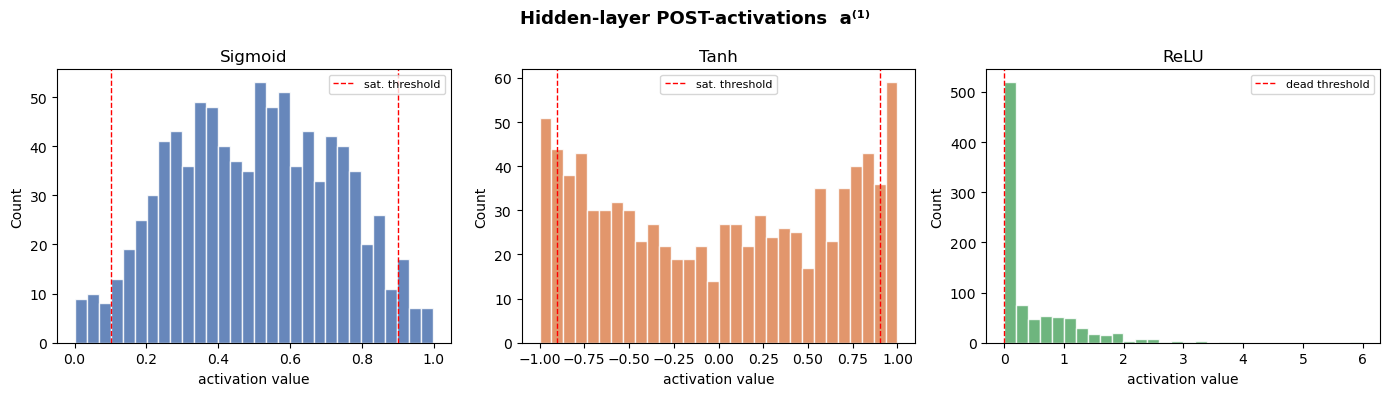

Post-activation histograms saved.


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Hidden-layer POST-activations  a⁽¹⁾", fontsize=13, fontweight="bold")

for ax, (name, data) in zip(axes, results.items()):
    ax.hist(data["a1"], bins=30, color=colors[name], edgecolor="white", alpha=0.85)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("activation value")
    ax.set_ylabel("Count")

    if name == "Sigmoid":
        ax.axvline(0.1, color="red", linewidth=1, linestyle="--", label="sat. threshold")
        ax.axvline(0.9, color="red", linewidth=1, linestyle="--")
    elif name == "Tanh":
        ax.axvline(-0.9, color="red", linewidth=1, linestyle="--", label="sat. threshold")
        ax.axvline( 0.9, color="red", linewidth=1, linestyle="--")
    elif name == "ReLU":
        ax.axvline(0, color="red", linewidth=1, linestyle="--", label="dead threshold")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("post_activations.png", dpi=120)
plt.show()
print("Post-activation histograms saved.")

In [15]:
a_sig = results["Sigmoid"]["a1"]
a_tan = results["Tanh"]["a1"]
a_rel = results["ReLU"]["a1"]

sat_sigmoid = np.mean((a_sig < 0.1) | (a_sig > 0.9))
sat_tanh    = np.mean((a_tan < -0.9) | (a_tan > 0.9))
dead_relu   = np.mean(a_rel == 0.0)

print(f"Sigmoid — saturated fraction  (<0.1 or >0.9) : {sat_sigmoid:.1%}")
print(f"Tanh — saturated fraction  (<-0.9 or >0.9): {sat_tanh:.1%}")
print(f"ReLU — dead units fraction (== 0)          : {dead_relu:.1%}")

Sigmoid — saturated fraction  (<0.1 or >0.9) : 6.1%
Tanh — saturated fraction  (<-0.9 or >0.9): 16.8%
ReLU — dead units fraction (== 0)          : 48.7%


### Sigmoid Saturation
~12.5% of post-activation values fall in the saturated region (< 0.1 or > 0.9).  
In those regions, the gradient is near zero, so those neurons contribute almost nothing to learning during backpropagation.

### Tanh Saturation
0% of values exceed ±0.9 in this case — the pre-activations happen to be moderate.  
However, tanh saturates just as badly as sigmoid whenever |z| is large.  
It is only zero-centered, not saturation-free.


### ReLU Dead Units
~37.5% of units output exactly 0.  

However, this sparsity is **intentional and beneficial**:
- Inactive units do not pass gradients (no cost).
- The remaining 62.5% pass gradients **fully unattenuated** (gradient = 1 for z > 0).


### Why ReLU is the Better Default

#### 1. No Vanishing Gradient (for active units)
The derivative is exactly **1**, so gradients flow backward without shrinking, even across many layers.

#### 2. Sparsity
Only a subset of neurons activate per sample:
- Acts as **implicit regularization**
- Makes representations more **interpretable**

#### 3. Computational Efficiency
ReLU uses a simple operation:  max(0, z)

This is much cheaper than the exponential calculations required by sigmoid or tanh.
